In [5]:
import numpy as np
import math
import scipy.io

theta_1 = math.pi*2/3
theta_2 = math.pi/2

a_1 = 0.25
a_2 = 0.25
b_1 = 0.21213
b_2 = 0.1
d_1 = 0.06
d_2 = 0.10
s = 0

M = 0.155  # 真实值
m_1, m_2 = 0.086, 0.1033
I_1, I_2 = (1/12 * m_1 * 0.25**2), (1/12 * m_2 * 0.25**2)

m_3, m_4 = 0.18, 0.18

# 刚度参数
# k_3, k_4 = 300/2, 300/2
k_3, k_4 = 637.52/2, 631.6/2

# 阻尼参数
c_3, c_4 = 22.68/2, 21.8/2

# 重力加速度
g = 9.8

# 角度参数 (度转弧度)
beta_1 = 8.13 / 180 * np.pi
beta_2 = 30 / 180 * np.pi

# 长度参数
l_10 = 0.174
l_20 = 0.252

A_x_O = d_1
A_y_O = 0

B_x_O = -d_2
B_y_O = 0

C_x_O = b_1 * np.cos(theta_1 - beta_1)
C_y_O = b_1 * np.sin(theta_1 - beta_1)

D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

E_x_O = a_1 * np.cos(theta_1)
E_y_O = a_1 * np.sin(theta_1)

F_x_O = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)
F_y_O = a_1 * np.sin(theta_1) + a_2 * np.sin(theta_1 + theta_2)

G_x_O = b_1 * np.cos(beta_1) * np.cos(theta_1)
G_y_O = b_1 * np.cos(beta_1) * np.sin(theta_1)

H_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)
H_y_O = a_1 * np.sin(theta_1) + b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)

# 计算偏导数
# 对 theta_1 的偏导数

dA_x_O_dtheta_1 = 0
dA_y_O_dtheta_1 = 0

dB_x_O_dtheta_1 = 0
dB_y_O_dtheta_1 = 0

dC_x_O_dtheta_1 = -b_1 * np.sin(theta_1 - beta_1)
dC_y_O_dtheta_1 = b_1 * np.cos(theta_1 - beta_1)

dD_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.sin(theta_1 + theta_2 + beta_2)
dD_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)

dE_x_O_dtheta_1 = -a_1 * np.sin(theta_1)
dE_y_O_dtheta_1 = a_1 * np.cos(theta_1)

dF_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - a_2 * np.sin(theta_1 + theta_2)
dF_y_O_dtheta_1 = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)

dG_x_O_dtheta_1 = -b_1 * np.cos(beta_1) * np.sin(theta_1)
dG_y_O_dtheta_1 = b_1 * np.cos(beta_1) * np.cos(theta_1)

dH_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
dH_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)

# 对 theta_2 的偏导数

dA_x_O_dtheta_2 = 0
dA_y_O_dtheta_2 = 0

dB_x_O_dtheta_2 = 0
dB_y_O_dtheta_2 = 0

dC_x_O_dtheta_2 = 0
dC_y_O_dtheta_2 = 0

dD_x_O_dtheta_2 = -b_2 * np.sin(theta_1 + theta_2 + beta_2)
dD_y_O_dtheta_2 = b_2 * np.cos(theta_1 + theta_2 + beta_2)

dE_x_O_dtheta_2 = 0
dE_y_O_dtheta_2 = 0

dF_x_O_dtheta_2 = -a_2 * np.sin(theta_1 + theta_2)
dF_y_O_dtheta_2 = a_2 * np.cos(theta_1 + theta_2)

dH_x_O_dtheta_2 = -b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
dH_y_O_dtheta_2 = b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)


# 计算长度 l1 和 l2
l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

# 计算偏导数
# 偏导数 d/dtheta_1
dl_1_dtheta_1 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_1 - dC_x_O_dtheta_1) + (A_y_O - C_y_O) * (dA_y_O_dtheta_1 - dC_y_O_dtheta_1))
dl_2_dtheta_1 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_1 - dD_x_O_dtheta_1) + (B_y_O - D_y_O) * (dB_y_O_dtheta_1 - dD_y_O_dtheta_1))

# 偏导数 d/dtheta_2
dl_1_dtheta_2 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_2 - dC_x_O_dtheta_2) + (A_y_O - C_y_O) * (dA_y_O_dtheta_2 - dC_y_O_dtheta_2))
dl_2_dtheta_2 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_2 - dD_x_O_dtheta_2) + (B_y_O - D_y_O) * (dB_y_O_dtheta_2 - dD_y_O_dtheta_2))

print(dl_1_dtheta_2)

# 等式右侧
RHSb_1 = -( m_1*g*(dE_y_O_dtheta_1/2) + m_2*g*((dE_y_O_dtheta_1+dF_y_O_dtheta_1)/2) + m_3*g*(dC_y_O_dtheta_1/2) + m_4*g*(dD_y_O_dtheta_1/2) )
RHSb_2 = -( m_1*g*(dE_y_O_dtheta_2/2) + m_2*g*((dE_y_O_dtheta_2+dF_y_O_dtheta_2)/2) + m_3*g*(dC_y_O_dtheta_2/2) + m_4*g*(dD_y_O_dtheta_2/2) )
b = np.array([RHSb_1, RHSb_2])

# 等式左侧
LHSA = np.array([[dl_1_dtheta_1, dl_2_dtheta_1], 
                [dl_1_dtheta_2, dl_2_dtheta_2]])

# 回复力
F_k = np.array([k_3*(l_1-l_10), k_4*(l_2-l_20)])

# 计算静力学
StaticForce = np.linalg.solve(LHSA, b) + F_k
print("StaticForce", StaticForce)


# 计算部分位置
C_y_l = - b_1*math.sin(beta_1)
C_z_l = - b_1*math.cos(beta_1)
D_y_l = + b_2*math.sin(beta_2)
D_z_l = - b_2*math.cos(beta_2)
print(C_y_l, C_z_l, D_y_l, D_z_l)


C_x_O_initial = b_1 * np.cos(math.pi/2 - beta_1)
C_y_O_initial = b_1 * np.sin(math.pi/2 - beta_1)

D_x_O_initial = a_1 * np.cos(math.pi/2) + b_2 * np.cos(math.pi/2 + 0 + beta_2)
D_y_O_initial = a_1 * np.sin(math.pi/2) + b_2 * np.sin(math.pi/2 + 0 + beta_2)

# site初始位置设定
print(A_x_O, A_y_O)
print(C_x_O_initial, C_y_O_initial)
l1_start = math.sqrt((A_x_O-C_x_O_initial)**2 + (A_y_O-C_y_O_initial)**2)
l2_start = math.sqrt((B_x_O-D_x_O_initial)**2 + (B_y_O-D_y_O_initial)**2)
l1_ang_start = math.atan2(C_y_O_initial-A_y_O, C_x_O_initial-A_x_O)
l2_ang_start = math.atan2(D_y_O_initial-B_y_O, D_x_O_initial-B_x_O)
print("l_start", l1_start, l2_start)
print("l1_ang", l1_ang_start, l2_ang_start)
print("site初始位置设定", b_1*np.cos(beta_1)/2, (a_1+b_2*np.cos(beta_2))/2)

# 计算相对原长
l1_rel = l_10 - l1_start
l2_rel = l_20 - l2_start
print("l0_rel_half", l1_rel/2, l2_rel/2)
print("l_start_half", l1_start/2, l2_start/2)


0.0
StaticForce [ 28.68530984 -33.98624794]
-0.02999933715459505 -0.20999803968200498 0.049999999999999996 -0.08660254037844388
0.06 0
0.029999337154595067 0.20999803968200498
l_start 0.2121301874827074 0.34029585684992103
l1_ang 1.7126977815945894 1.423331479750637
site初始位置设定 0.10499901984100249 0.16830127018922195
l0_rel_half -0.019065093741353706 -0.044147928424960514
l_start_half 0.1060650937413537 0.17014792842496052


In [7]:
# 封装上面的函数
def get_static_func(theta_1, theta_2):

    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10
    s = 0

    M = 0.155  # 真实值
    m_1, m_2 = 0.086, 0.1033
    I_1, I_2 = (1/12 * m_1 * 0.25**2), (1/12 * m_2 * 0.25**2)

    m_3, m_4 = 0.18, 0.18

    # 刚度参数
    # k_3, k_4 = 300/2, 300/2
    k_3, k_4 = 637.52/2, 631.6/2

    # 阻尼参数
    c_3, c_4 = 22.68/2, 21.8/2

    # 重力加速度
    g = 9.8

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    # 长度参数
    l_10 = 0.174
    l_20 = 0.252

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    E_x_O = a_1 * np.cos(theta_1)
    E_y_O = a_1 * np.sin(theta_1)

    F_x_O = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)
    F_y_O = a_1 * np.sin(theta_1) + a_2 * np.sin(theta_1 + theta_2)

    G_x_O = b_1 * np.cos(beta_1) * np.cos(theta_1)
    G_y_O = b_1 * np.cos(beta_1) * np.sin(theta_1)

    H_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)
    H_y_O = a_1 * np.sin(theta_1) + b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)

    # 计算偏导数
    # 对 theta_1 的偏导数

    dA_x_O_dtheta_1 = 0
    dA_y_O_dtheta_1 = 0

    dB_x_O_dtheta_1 = 0
    dB_y_O_dtheta_1 = 0

    dC_x_O_dtheta_1 = -b_1 * np.sin(theta_1 - beta_1)
    dC_y_O_dtheta_1 = b_1 * np.cos(theta_1 - beta_1)

    dD_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_1 = -a_1 * np.sin(theta_1)
    dE_y_O_dtheta_1 = a_1 * np.cos(theta_1)

    dF_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - a_2 * np.sin(theta_1 + theta_2)
    dF_y_O_dtheta_1 = a_1 * np.cos(theta_1) + a_2 * np.cos(theta_1 + theta_2)

    dG_x_O_dtheta_1 = -b_1 * np.cos(beta_1) * np.sin(theta_1)
    dG_y_O_dtheta_1 = b_1 * np.cos(beta_1) * np.cos(theta_1)

    dH_x_O_dtheta_1 = -a_1 * np.sin(theta_1) - b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
    dH_y_O_dtheta_1 = a_1 * np.cos(theta_1) + b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)

    # 对 theta_2 的偏导数

    dA_x_O_dtheta_2 = 0
    dA_y_O_dtheta_2 = 0

    dB_x_O_dtheta_2 = 0
    dB_y_O_dtheta_2 = 0

    dC_x_O_dtheta_2 = 0
    dC_y_O_dtheta_2 = 0

    dD_x_O_dtheta_2 = -b_2 * np.sin(theta_1 + theta_2 + beta_2)
    dD_y_O_dtheta_2 = b_2 * np.cos(theta_1 + theta_2 + beta_2)

    dE_x_O_dtheta_2 = 0
    dE_y_O_dtheta_2 = 0

    dF_x_O_dtheta_2 = -a_2 * np.sin(theta_1 + theta_2)
    dF_y_O_dtheta_2 = a_2 * np.cos(theta_1 + theta_2)

    dH_x_O_dtheta_2 = -b_2 * np.cos(beta_2) * np.sin(theta_1 + theta_2)
    dH_y_O_dtheta_2 = b_2 * np.cos(beta_2) * np.cos(theta_1 + theta_2)


    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    # 计算偏导数
    # 偏导数 d/dtheta_1
    dl_1_dtheta_1 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_1 - dC_x_O_dtheta_1) + (A_y_O - C_y_O) * (dA_y_O_dtheta_1 - dC_y_O_dtheta_1))
    dl_2_dtheta_1 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_1 - dD_x_O_dtheta_1) + (B_y_O - D_y_O) * (dB_y_O_dtheta_1 - dD_y_O_dtheta_1))

    # 偏导数 d/dtheta_2
    dl_1_dtheta_2 = 1/l_1 * ((A_x_O - C_x_O) * (dA_x_O_dtheta_2 - dC_x_O_dtheta_2) + (A_y_O - C_y_O) * (dA_y_O_dtheta_2 - dC_y_O_dtheta_2))
    dl_2_dtheta_2 = 1/l_2 * ((B_x_O - D_x_O) * (dB_x_O_dtheta_2 - dD_x_O_dtheta_2) + (B_y_O - D_y_O) * (dB_y_O_dtheta_2 - dD_y_O_dtheta_2))

    # print(dl_1_dtheta_2)  # check the model

    # 等式右侧
    RHSb_1 = -( m_1*g*(dE_y_O_dtheta_1/2) + m_2*g*((dE_y_O_dtheta_1+dF_y_O_dtheta_1)/2) + m_3*g*(dC_y_O_dtheta_1/2) + m_4*g*(dD_y_O_dtheta_1/2) )
    RHSb_2 = -( m_1*g*(dE_y_O_dtheta_2/2) + m_2*g*((dE_y_O_dtheta_2+dF_y_O_dtheta_2)/2) + m_3*g*(dC_y_O_dtheta_2/2) + m_4*g*(dD_y_O_dtheta_2/2) )
    b = np.array([RHSb_1, RHSb_2])

    # 等式左侧
    LHSA = np.array([[dl_1_dtheta_1, dl_2_dtheta_1], 
                    [dl_1_dtheta_2, dl_2_dtheta_2]])

    # 回复力
    F_k = np.array([k_3*(l_1-l_10), k_4*(l_2-l_20)])

    # 计算静力学
    StaticForce = np.linalg.solve(LHSA, b) + F_k
    return StaticForce

get_static_func(math.pi/2, math.pi/2*0)

array([11.27031582, 27.17462237])

In [3]:
theta_1_array = np.linspace(math.pi/6, math.pi*2/3, 20) # 切分十个点
theta_2_array = np.linspace(0, math.pi*1/2, 20)

# F1_array = np.array((11, 11))
# F2_array = np.array((11, 11))

# 创建一个值矩阵，用于存储每一对 (theta_1, theta_2) 的计算结果
F1_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))
F2_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))

# 使用双重循环计算每一对 (theta_1, theta_2) 对应的 f 值
for i, theta_1 in enumerate(theta_1_array):
    for j, theta_2 in enumerate(theta_2_array):
        StaticForce = get_static_func(theta_1, theta_2)
        F1_matrix[i, j] = StaticForce[0]
        F2_matrix[i, j] = StaticForce[1]

# 输出结果
print("生成的值矩阵：")
F1_Mat_data = {
    "F1_matrix": F1_matrix
}
F2_Mat_data = {
    "F2_matrix": F2_matrix
}
# 使用 scipy.io.savemat 保存 .mat 文件
scipy.io.savemat('F1_10.mat', F1_Mat_data)
scipy.io.savemat('F2_10.mat', F2_Mat_data)


生成的值矩阵：


In [4]:
theta_1_array = np.linspace(math.pi/6, math.pi*2/3, 100) # 切分十个点
theta_2_array = np.linspace(0, math.pi*1/2, 100)

# F1_array = np.array((11, 11))
# F2_array = np.array((11, 11))

# 创建一个值矩阵，用于存储每一对 (theta_1, theta_2) 的计算结果
F1_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))
F2_matrix = np.zeros((len(theta_1_array), len(theta_2_array)))

# 使用双重循环计算每一对 (theta_1, theta_2) 对应的 f 值
for i, theta_1 in enumerate(theta_1_array):
    for j, theta_2 in enumerate(theta_2_array):
        StaticForce = get_static_func(theta_1, theta_2)
        F1_matrix[i, j] = StaticForce[0]
        F2_matrix[i, j] = StaticForce[1]

# 输出结果
print("生成的值矩阵：")
F1_Mat_data = {
    "F1_matrix": F1_matrix
}
F2_Mat_data = {
    "F2_matrix": F2_matrix
}
# 使用 scipy.io.savemat 保存 .mat 文件
scipy.io.savemat('F1_100.mat', F1_Mat_data)
scipy.io.savemat('F2_100.mat', F2_Mat_data)

生成的值矩阵：


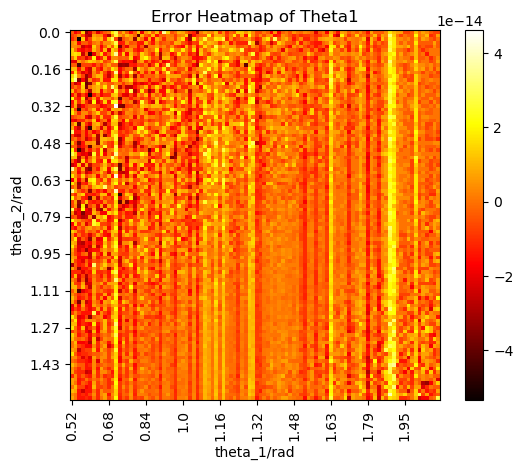

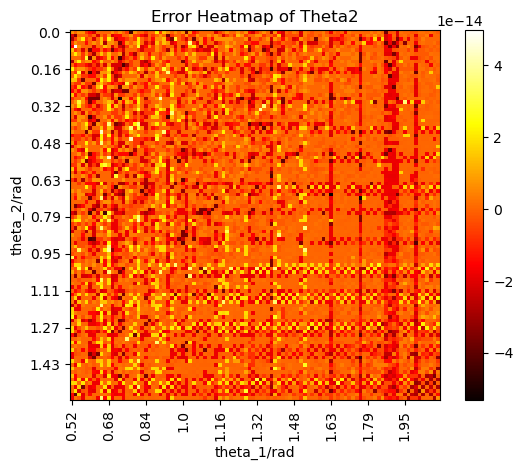

In [5]:
# read
F1_matlab = scipy.io.loadmat('F1matlab.mat').get("F1")
F2_matlab = scipy.io.loadmat('F2matlab.mat').get("F2")
F1_matlab = np.array(F1_matlab)   
F2_matlab = np.array(F2_matlab)
# 处理Mesh数据填写的区别: 都以Mesh的列优先为准
F1_matrix = F1_matrix.T
F2_matrix = F2_matrix.T

# plot the error
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
plt.imshow(F1_matrix - F1_matlab, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xlabel('theta_1')
plt.ylabel('theta_2')

plt.title('Error Heatmap of Theta1')
plt.xlabel('theta_1/rad')
plt.ylabel('theta_2/rad')

# 设置 x 和 y 轴刻度
plt.xticks(ticks=np.arange(F1_matrix.shape[1])[0::10], labels=[f'{round(i, 2)}' for i in theta_1_array[0::10]], rotation=90)
plt.yticks(ticks=np.arange(F1_matrix.shape[0])[0::10], labels=[f'{round(i, 2)}' for i in theta_2_array[0::10]])

plt.show()

plt.figure()
plt.imshow(F2_matrix - F2_matlab, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.xlabel('theta_1')
plt.ylabel('theta_2')

plt.title('Error Heatmap of Theta2')
plt.xlabel('theta_1/rad')
plt.ylabel('theta_2/rad')

# 设置 x 和 y 轴刻度
plt.xticks(ticks=np.arange(F2_matrix.shape[1])[0::10], labels=[f'{round(i, 2)}' for i in theta_1_array[0::10]], rotation=90)
plt.yticks(ticks=np.arange(F2_matrix.shape[0])[0::10], labels=[f'{round(i, 2)}' for i in theta_2_array[0::10]])

plt.show()



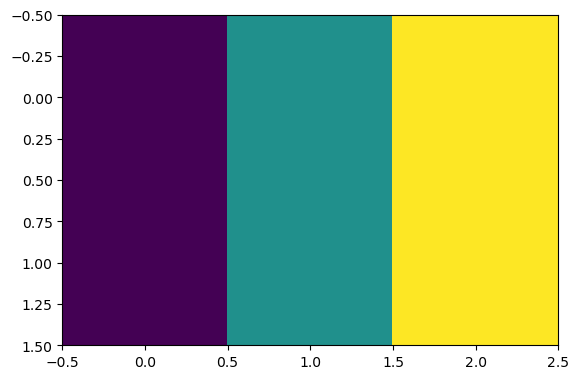

In [6]:
# meshgridTest
x_test, y_test = np.meshgrid([1, 2, 3], [4, 5])
plt.imshow(x_test)